# **Objective**

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year.The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having a higher chance of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You, as a data scientist at EasyVisa, have to analyze the data provided and, with the help of a classification model:

1.Facilitate the process of visa approvals.
2.Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

# **Data Description**

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

**case_id:** ID of each visa application

**continent:** Information of continent the employee

**education_of_employee:** Information of education of the employee

**has_job_experience:** Does the employee have any job experience? Y= Yes; N = No

**requires_job_training:** Does the employee require any job training? Y = Yes; N = No

**no_of_employees:** Number of employees in the employer's company

**yr_of_estab:** Year in which the employer's company was established

**region_of_employment:** Information of foreign worker's intended region of employment in the US.

**prevailing_wage:** Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.

**unit_of_wage:** Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.

**full_time_position:** Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position

**case_status:** Flag indicating if the Visa was certified or denied

In [ ]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Library to split data
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns


# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Libraries to get different metric scores
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To tune different models
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler


from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier


sc = StandardScaler()

In [ ]:
data = pd.read_csv("/content/EasyVisa.csv")

In [ ]:
df = data.copy()

In [ ]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


no_of_employees and yr_of_estab is integer while others is Object

prevailing is float

Not Null Values  in the dataset

In [ ]:
df.shape

(25480, 12)

dataset have 12 columns and 25480 rows

In [ ]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


### Observations  (numerical columns):

*   **no_of_employees:**
    *   The minimum value is -26. This is **anomalous** as the number of employees cannot be negative. This data point needs to be addressed.
    *   The maximum value is very high (602,069), indicating a wide range in company sizes, possibly with some outliers.
    *   The mean is approximately 5,667, but the large standard deviation (22,877) suggests a very spread-out distribution, likely skewed by the large maximum value.

*   **yr_of_estab (Year of Establishment):**
    *   The minimum year is 1800. This could be an **outlier** or a data entry error, as most companies are established much more recently. This also needs attention.
    *   The maximum year is 2016.
    *   The average establishment year is around 1979.

*   **prevailing_wage:**
    *   Wages range widely from a minimum of about 2.14 to a maximum of 319,210.27.
    *   The average prevailing wage is approximately 74,455.81. The large standard deviation (52,815.94) confirms the significant variability in wages.

In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV25480,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###  Observations:

*   **No Missing Data**: All columns are complete (25480 entries).
*   **case_id**: Each entry is unique, acting as an ID.

*   **Categorical Columns (Text)**:
    *   Many have only two options (like 'Y'/'N' or 'Certified'/'Denied'). Most applications have job experience, are full-time, don't need training, and are certified.
    *   'Asia' is the most common continent, 'Bachelor's' is the most frequent education, and 'Year' is the most common wage unit.

*   **Numerical Columns (Numbers)**:
    *   **no_of_employees**: Has a minimum of **-26**, which is impossible and needs fixing. Some companies are very large.
    *   **yr_of_estab**: Has a minimum of **1800**, which seems too old and might be an error.
    *   **prevailing_wage**: Shows a very wide range, from very low to very high, indicating diverse salaries.

In [ ]:
df.nunique()

,0
case_id,25480
continent,6
education_of_employee,4
has_job_experience,2
requires_job_training,2
no_of_employees,7105
yr_of_estab,199
region_of_employment,5
prevailing_wage,25454
unit_of_wage,4


In [ ]:
df.value_counts('case_status')

,count
case_status,
Certified,17018
Denied,8462


data have 17018 Certified Cases and 8462 Denied cases

# **Checking for duplicate values**

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicate values in the data.

# **Checking for missing values**

In [ ]:
df.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


There are no Missing values in the data.

### **Handling Anomalous Values**

From **df.describe()** output, we identified the following anomalies:

*   **no_of_employees**: The minimum value is -26, which is invalid. We will replace negative values with the median.
*   **yr_of_estab**: The minimum value is 1800, which might be an outlier or data entry error. We will replace values less than 1900 with the median.

In [ ]:
# Calculate the median for 'no_of_employees' and 'yr_of_estab'
median_no_of_employees = df['no_of_employees'].median()
median_yr_of_estab = df['yr_of_estab'].median()

# Replace negative 'no_of_employees' with the median
df.loc[df['no_of_employees'] < 0, 'no_of_employees'] = median_no_of_employees

# Replace 'yr_of_estab' values less than 1900 with the median
df.loc[df['yr_of_estab'] < 1900, 'yr_of_estab'] = median_yr_of_estab

print("Anomalous values handled.")


Anomalous values handled.


In [ ]:
# Verify the changes by checking describe again for these columns
display(df[['no_of_employees', 'yr_of_estab']].describe())

,no_of_employees,yr_of_estab
count,25480.000000,25480.000000
mean,5669.797645,1990.556201
std,22877.372247,22.661591
min,12.000000,1900.000000
25%,1028.000000,1985.000000
50%,2109.000000,1997.000000
75%,3504.000000,2005.000000
max,602069.000000,2016.000000


### **Exploring Categorical Features**

In [ ]:
# Get list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Categorical Columns:", categorical_cols)


Categorical Columns: ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [ ]:
# Display unique values and their counts for each categorical column
for col in categorical_cols:
    print(f"\nUnique values and counts for '{col}':")
    print(df[col].value_counts())



Unique values and counts for 'case_id':
case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64

Unique values and counts for 'continent':
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

Unique values and counts for 'education_of_employee':
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64

Unique values and counts for 'has_job_experience':
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64

Unique values and counts for 'requires_job_training':
requires_job_training
N    22525
Y     2955
Name: count, dtype: int64

Unique values and counts for 'region_of_employment':
region_of_employment
Northeast    7195
Sout

# **Exploratory Data Analysis (EDA)**

# **Univariate Analysis**

In [ ]:
print(df.columns)

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')


### **Visualize the distribution of numerical columns**

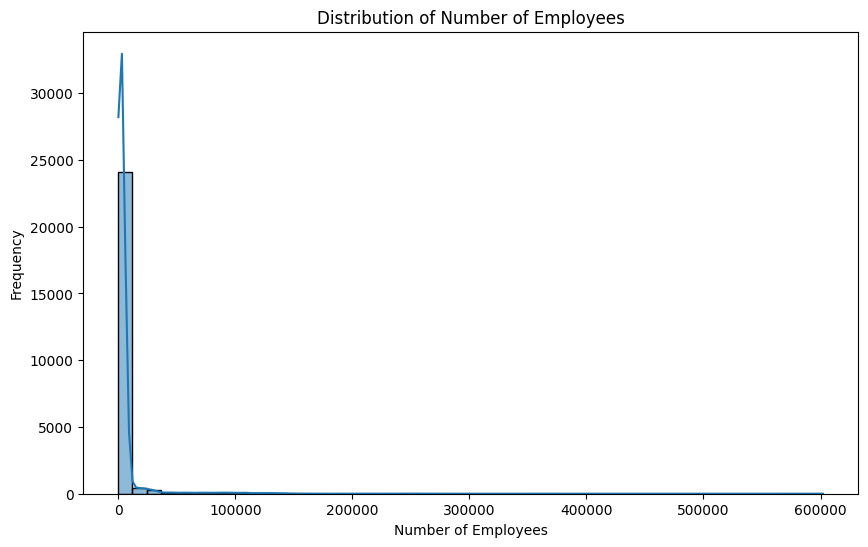

In [ ]:
# Visualize the distribution of 'no_of_employees'
plt.figure(figsize=(10, 6))
sns.histplot(df['no_of_employees'], bins=50, kde=True)
plt.title('Distribution of Number of Employees')
plt.xlabel('Number of Employees')
plt.ylabel('Frequency')
plt.show()

Distribution of Number of Employees:

 This plot is highly skewed to the right. A large majority of companies have a small number of employees, with a few very large companies forming a long tail. This indicates that most of the employers are small to medium-sized.

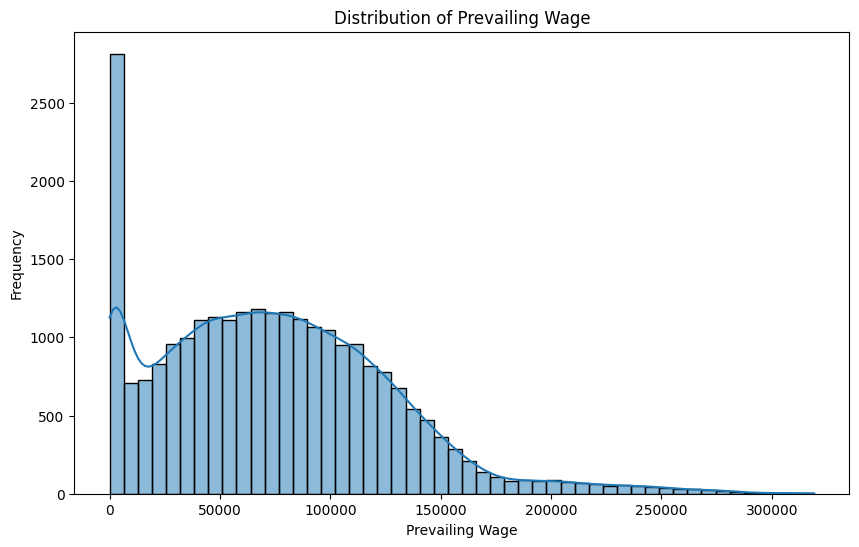

In [ ]:
# Visualize the distribution of 'prevailing_wage'
plt.figure(figsize=(10, 6))
sns.histplot(df['prevailing_wage'], bins=50, kde=True)
plt.title('Distribution of Prevailing Wage')
plt.xlabel('Prevailing Wage')
plt.ylabel('Frequency')
plt.show()

Distribution of Prevailing Wage:

 The distribution of 'prevailing_wage' appears to be somewhat right-skewed as well, with a peak around the 50,000 to 100,000 range. This suggests that a significant portion of the applications are for positions with wages in this bracket, but there are also applications for both much lower and much higher wages.

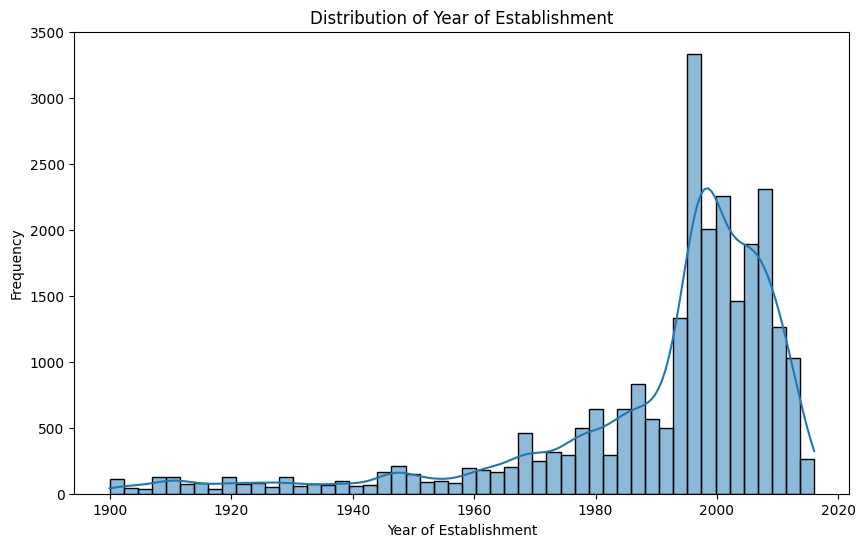

In [ ]:
# Visualize the distribution of 'yr_of_estab'
plt.figure(figsize=(10, 6))
sns.histplot(df['yr_of_estab'], bins=50, kde=True)
plt.title('Distribution of Year of Establishment')
plt.xlabel('Year of Establishment')
plt.ylabel('Frequency')
plt.show()

Distribution of Year of Establishment:

 This plot shows a clear trend of increasing company establishments over time, with a prominent peak in the late 1990s and early 2000s. There are fewer companies established in earlier periods, which is expected.

### **Boxplot Visualization for Numerical Columns**

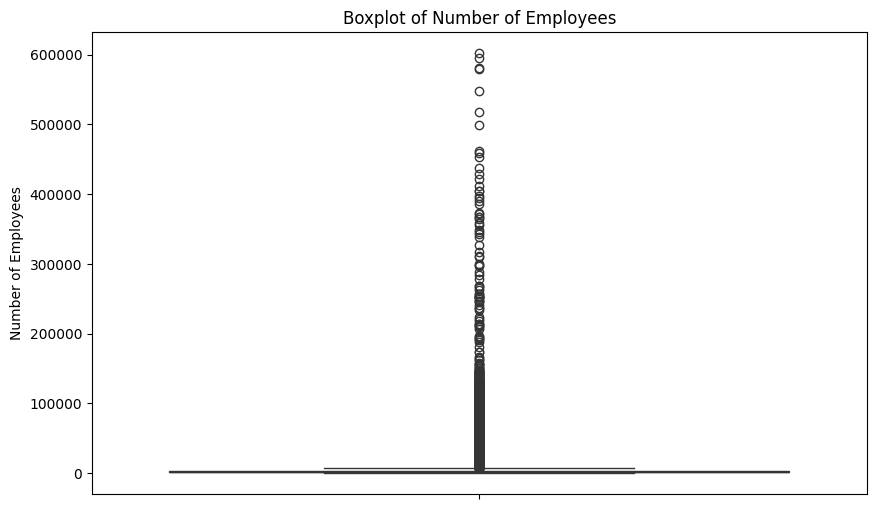

In [ ]:
# Boxplot for 'no_of_employees'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['no_of_employees'], palette='viridis')
plt.title('Boxplot of Number of Employees')
plt.ylabel('Number of Employees')
plt.show()

### Observations (Boxplot of Number of Employees):

*   **Median and Quartiles:** The box is very compressed at the lower end, indicating that the median and interquartile range are very low. This confirms that the vast majority of companies have a small number of employees.
*   **Outliers:** There are a significant number of extreme outliers extending far above the upper whisker. These represent companies with an exceptionally high number of employees, which aligns with the right-skewness observed in the histogram.

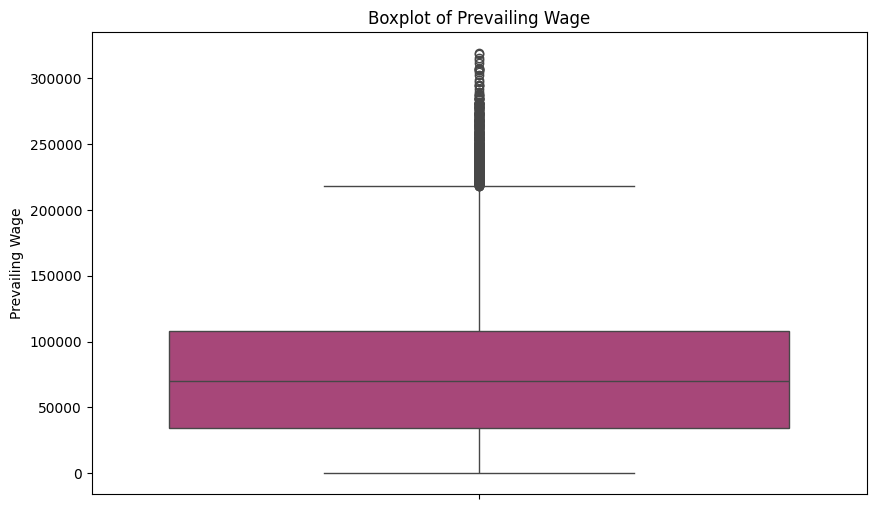

In [ ]:
# Boxplot for 'prevailing_wage'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['prevailing_wage'], palette='magma')
plt.title('Boxplot of Prevailing Wage')
plt.ylabel('Prevailing Wage')
plt.show()

### Observations (Boxplot of Prevailing Wage):

*   **Median and Quartiles:** The median wage is clearly visible within the box, and the spread of the interquartile range indicates the central 50% of wages. The box appears somewhat centered within the lower range of the data.
*   **Outliers:** Similar to 'no_of_employees', there are many outliers above the upper whisker, suggesting that a number of positions offer significantly higher prevailing wages than the majority. The absence of outliers below the lower whisker indicates that the minimum wage is not considered an extreme outlier relative to the dataset's lower bound after cleaning.

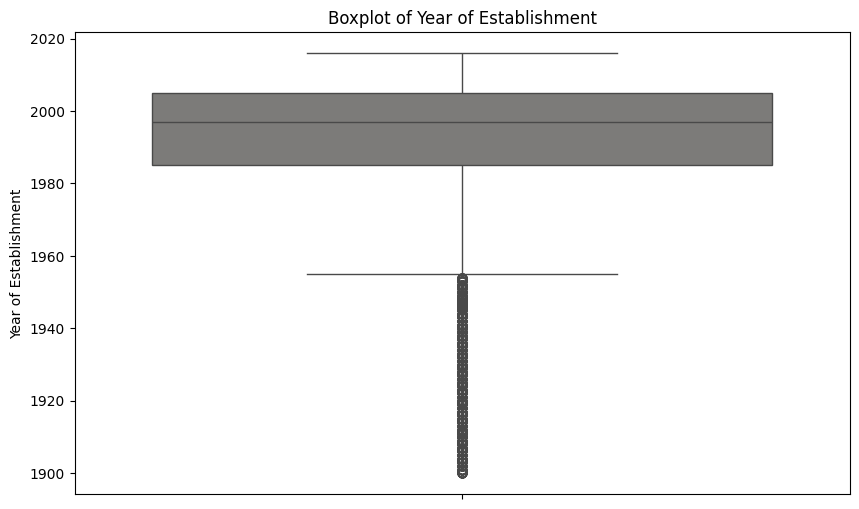

In [ ]:
# Boxplot for 'yr_of_estab'
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['yr_of_estab'], palette='cividis')
plt.title('Boxplot of Year of Establishment')
plt.ylabel('Year of Establishment')
plt.show()

### Observations (Boxplot of Year of Establishment):

*   **Median and Quartiles:** The box for 'yr_of_estab' is positioned towards the higher end of the timeline, confirming that most companies were established more recently. The median is likely around the late 1990s or early 2000s.
*   **Outliers:** There are outliers extending below the lower whisker, representing companies established in earlier years (e.g., in the early 20th century or even 19th century, after anomaly handling). These older companies are less common compared to the newer establishments.

### **Visualize the distribution of categorical columns**

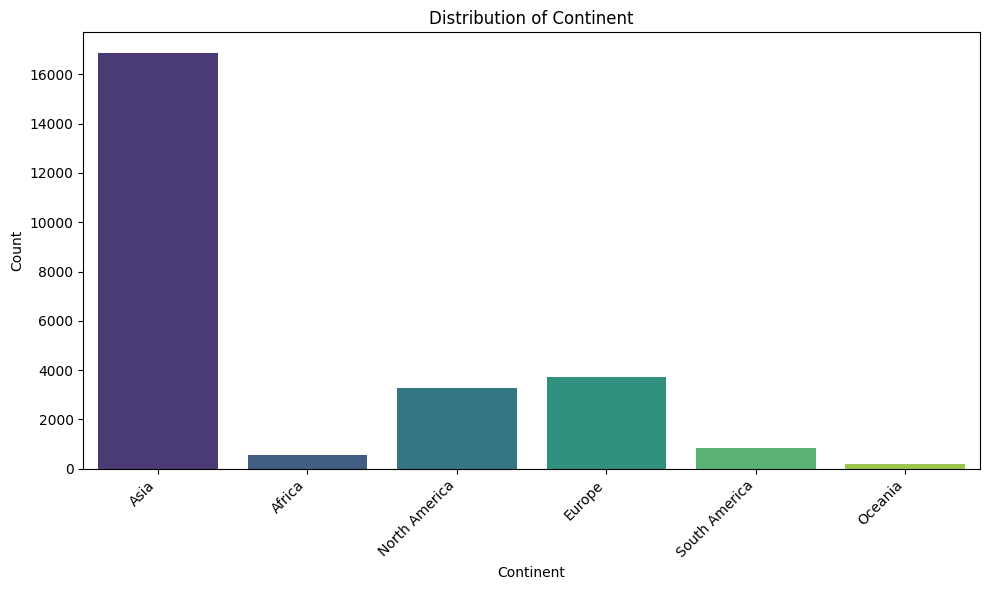

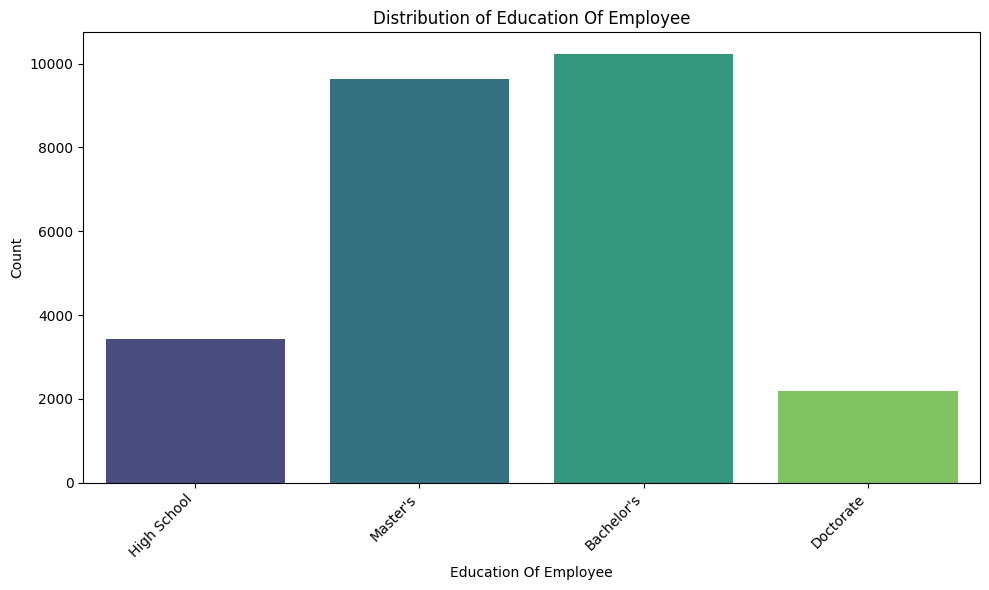

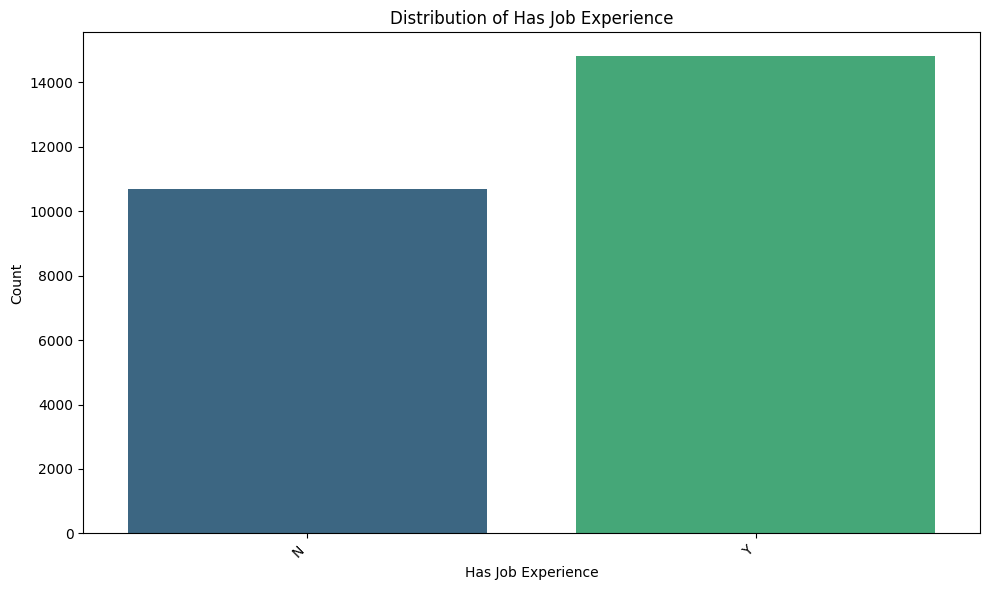

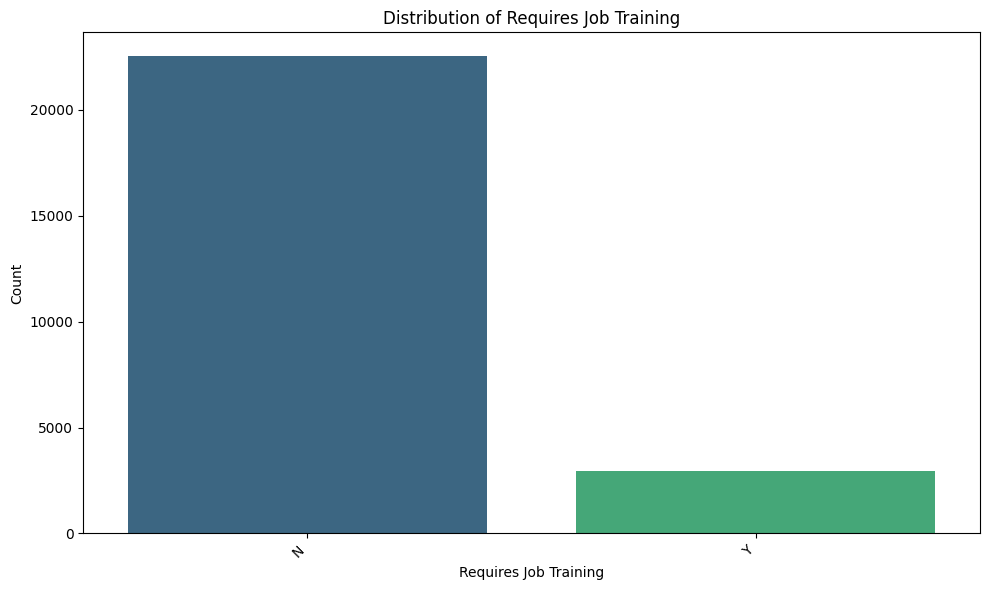

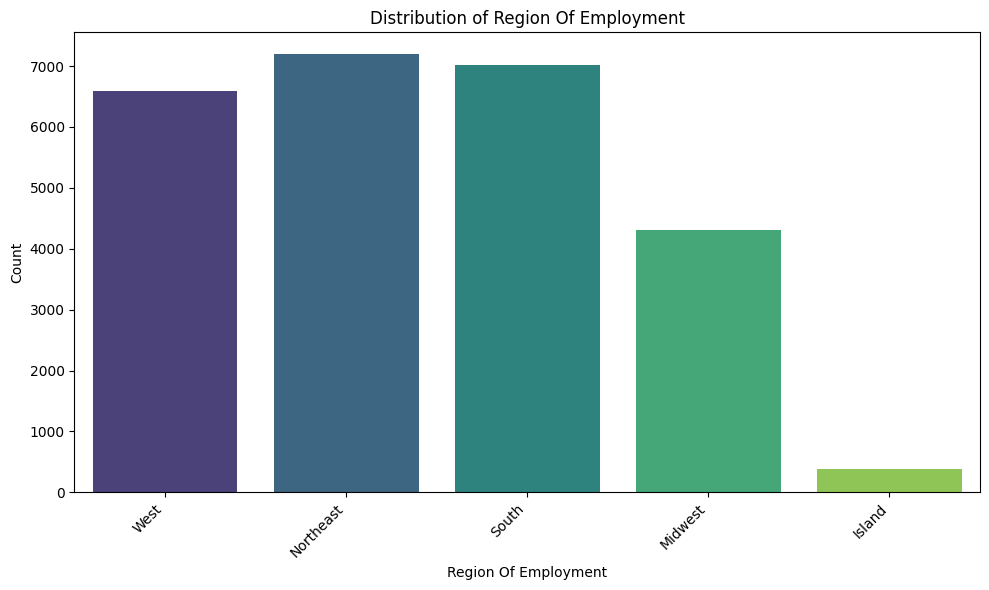

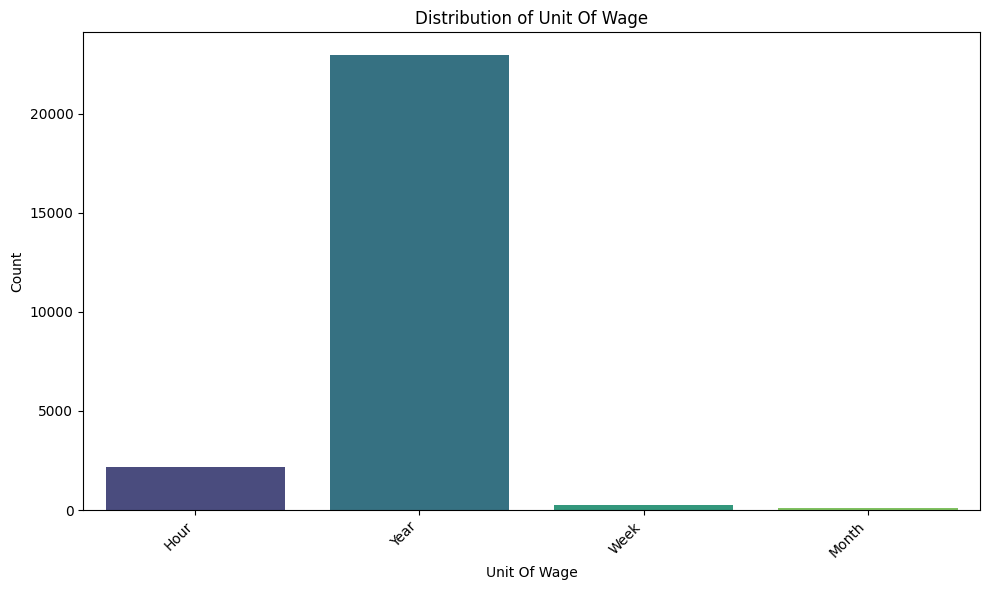

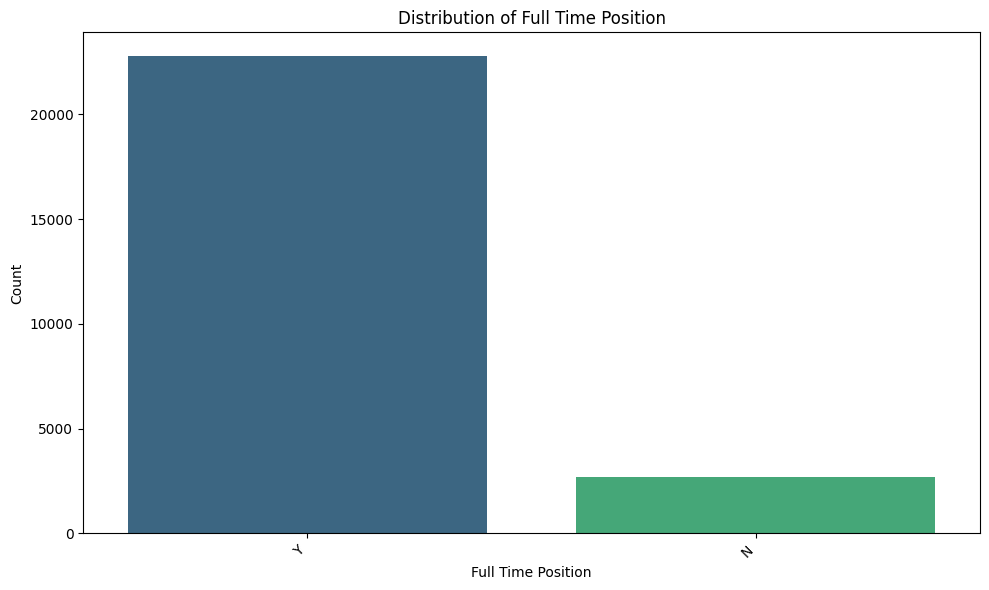

In [ ]:
# Get list of categorical columns, excluding 'case_id' and 'case_status' as they are unique identifiers or the target variable.
categorical_cols_for_plot = [col for col in categorical_cols if col not in ['case_id', 'case_status']]

for col in categorical_cols_for_plot:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### Observations (Categorical Columns):

*   **Continent:** A vast majority of applicants are from Asia, followed by Europe and North America. Africa, South America, and Oceania have significantly fewer applicants. This indicates a strong geographical concentration in the dataset.

*   **Education of Employee:** 'Bachelor's' and 'Master's' degrees are the most common educational qualifications among employees, followed by 'High School' and 'Doctorate'. This suggests that a higher education level is prevalent among visa applicants.

*   **Has Job Experience:** More employees have job experience ('Y') than those who do not ('N'). This implies that job experience is a common characteristic among applicants.

*   **Requires Job Training:** Most employees do not require job training ('N'), with a much smaller proportion requiring it ('Y'). This could mean that most applicants are already skilled and ready for their positions.

*   **Region of Employment:** The 'Northeast' and 'South' regions are the most common regions of employment, followed closely by 'West'. 'Midwest' has a moderate number, and 'Island' has the fewest. This highlights the preferred geographical areas for employment within the US.

*   **Unit of Wage:** 'Year' is by far the most common unit for prevailing wage, indicating that most salaries are reported annually. 'Hour' is the next most frequent, while 'Week' and 'Month' are much less common.

*   **Full-Time Position:** A significant majority of positions are full-time ('Y'), with very few being part-time ('N'). This suggests that most visa applications are for full-time employment opportunities.

# **Bivariate Analysis**

### **Bivariate Analysis - Categorical vs Case Status**

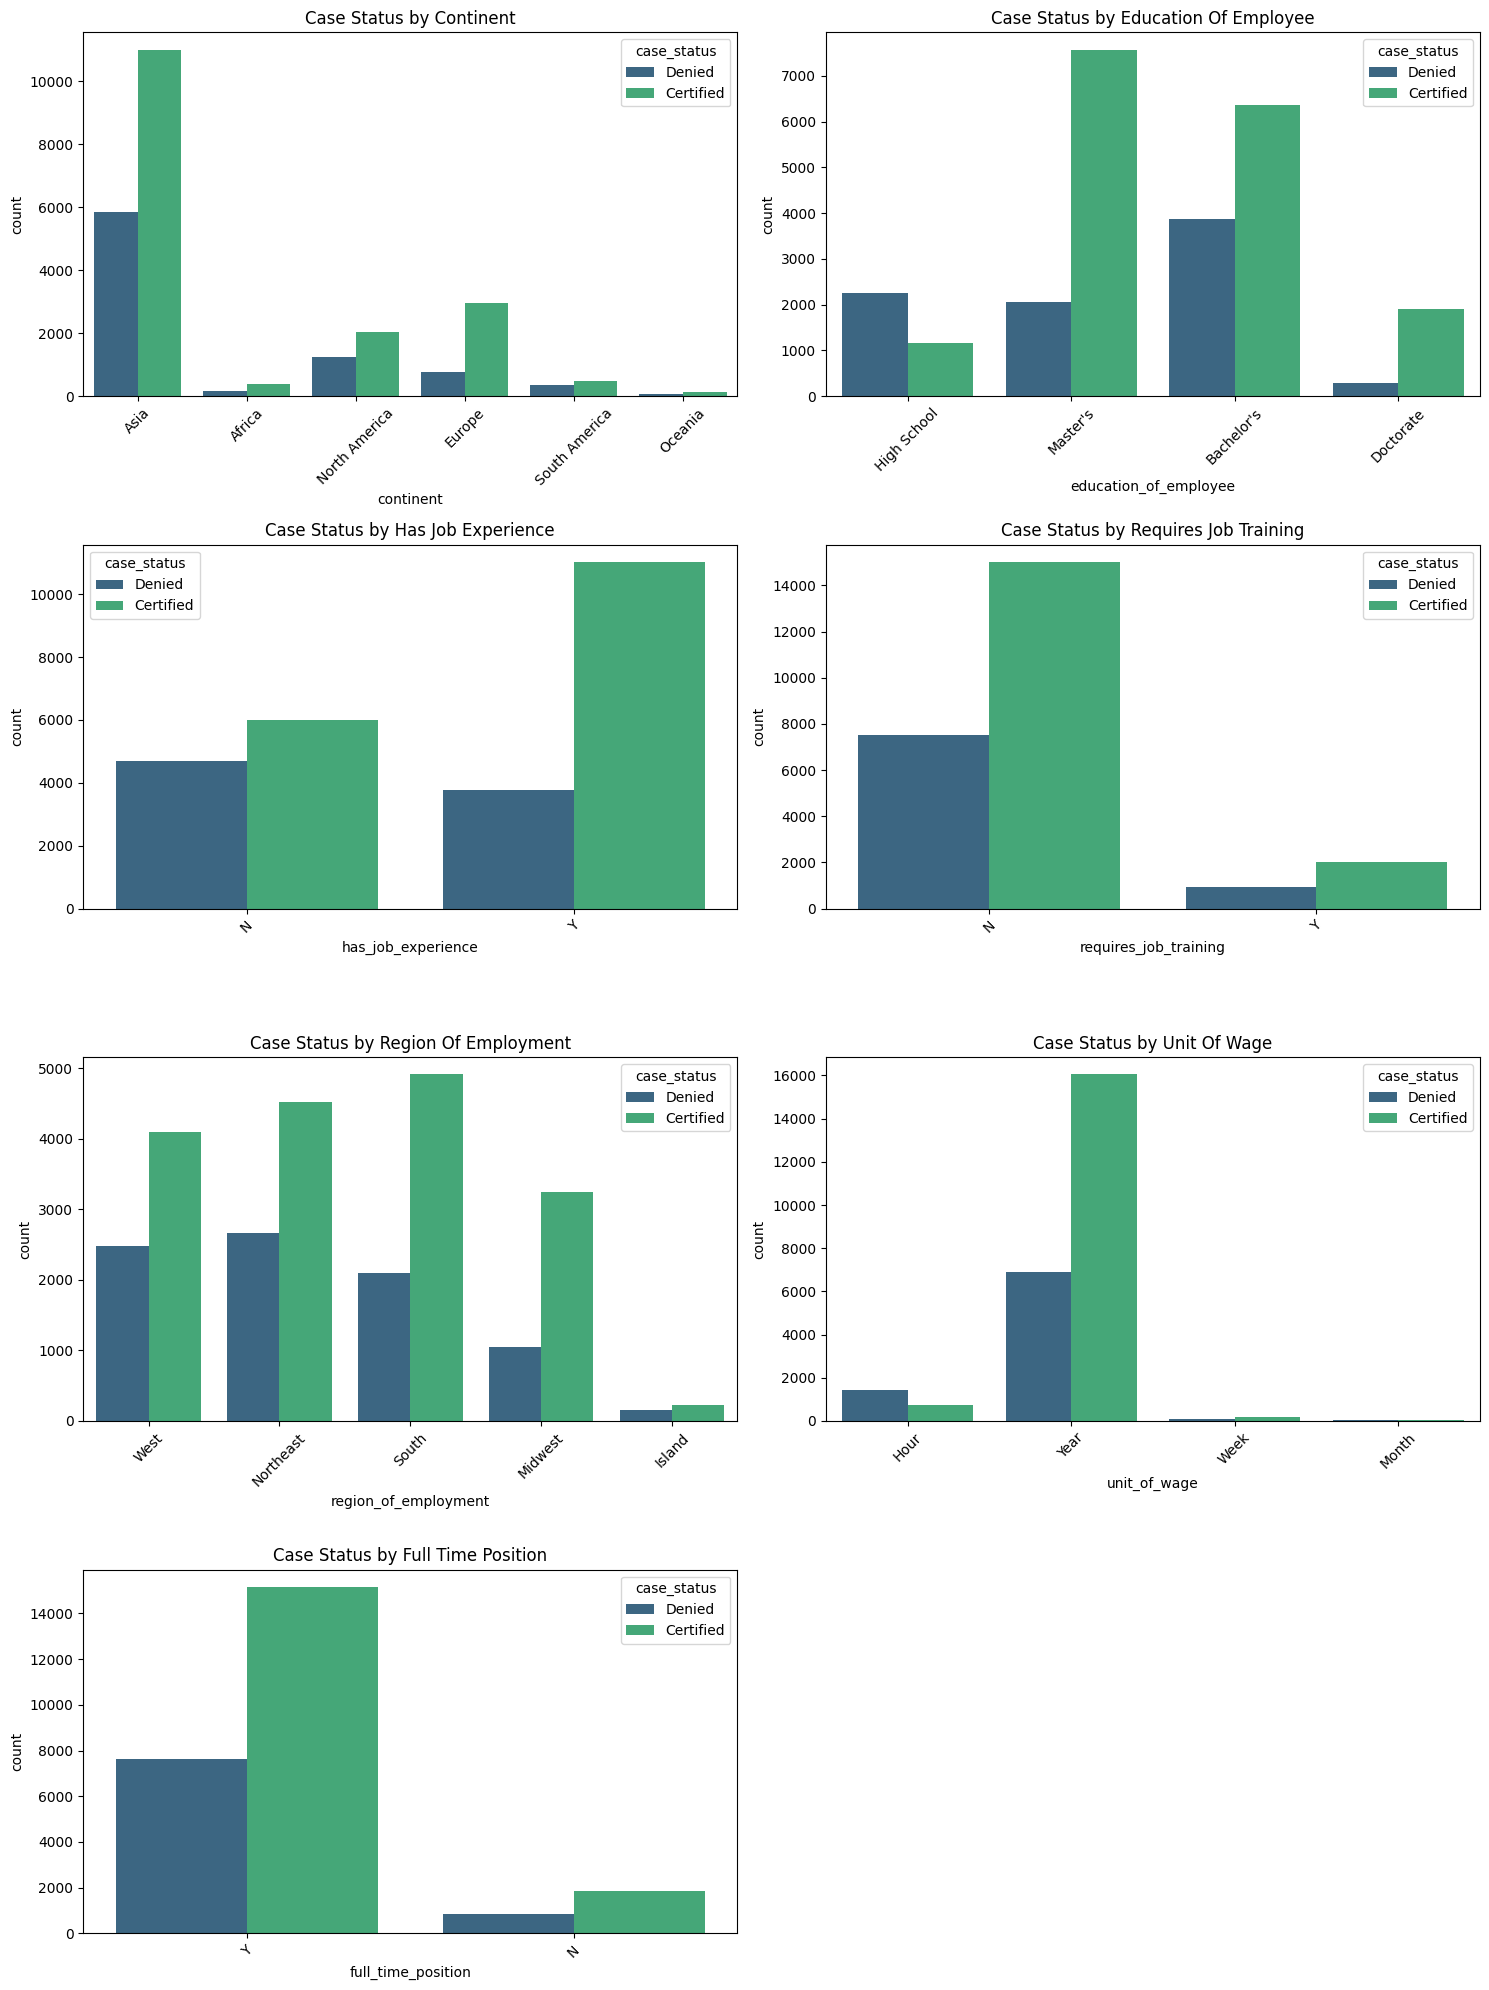

In [ ]:
plt.figure(figsize=(15, 20))
for i, variable in enumerate(categorical_cols_for_plot):
    plt.subplot(4, 2, i + 1)
    sns.countplot(data=df, x=variable, hue='case_status', palette='viridis')
    plt.title(f'Case Status by {variable.replace("_", " ").title()}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observations:
- **Education:** Higher education levels like Master's and Doctorate show higher certification rates compared to High School graduates.
- **Experience:** Applicants with job experience have a significantly higher likelihood of getting their visa certified.
- **Region:** The distribution of certification seems fairly consistent across major regions, though the Northeast and South have higher volumes of applications.
- **Training:** Those not requiring job training are more frequently certified.

### **Bivariate Analysis - Numerical vs Case Status**

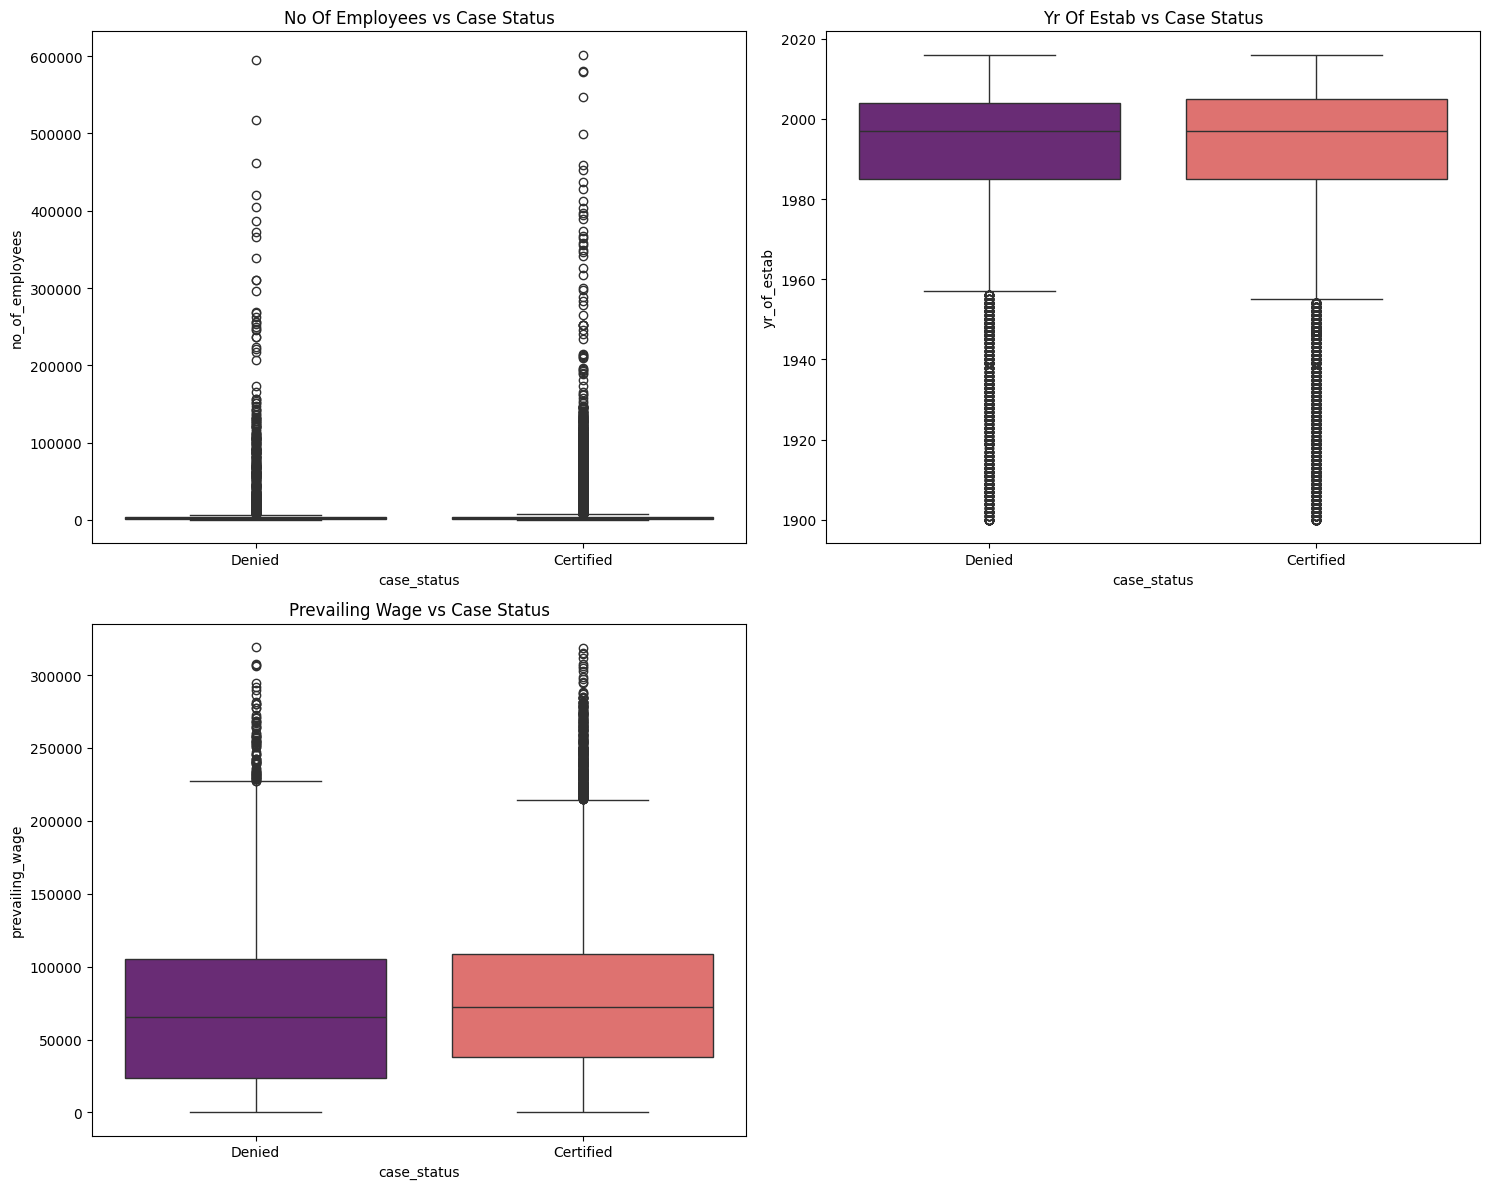

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))
for i, variable in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(data=df, x='case_status', y=variable, palette='magma')
    plt.title(f'{variable.replace("_", " ").title()} vs Case Status')

plt.tight_layout()
plt.show()

### Observations:
- **Prevailing Wage:** Certified cases tend to have a slightly higher median prevailing wage compared to denied cases.
- **Year of Establishment:** The age of the company does not appear to have a drastic impact on the median certification status, though newer companies show a high volume of both outcomes.
- **Number of Employees:** No major visible difference in the median size of the company for certified vs denied cases, though outliers exist in both.

### **Bivariate Analysis - Scatter Plot**

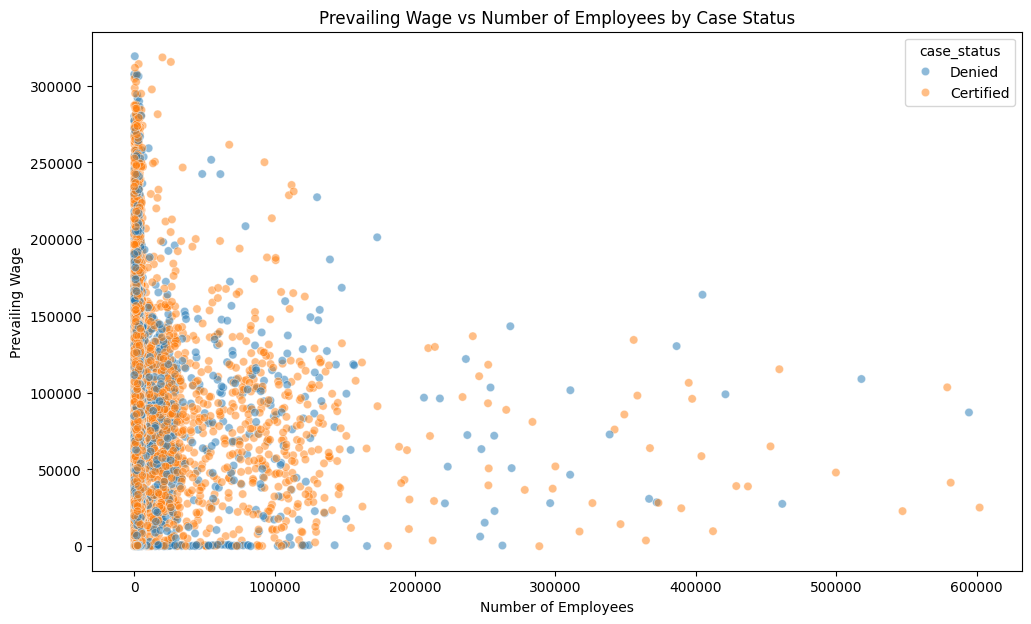

In [ ]:
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='no_of_employees', y='prevailing_wage', hue='case_status', alpha=0.5)
plt.title('Prevailing Wage vs Number of Employees by Case Status')
plt.xlabel('Number of Employees')
plt.ylabel('Prevailing Wage')
plt.show()

### **Bivariate Analysis - Correlation Heatmap**

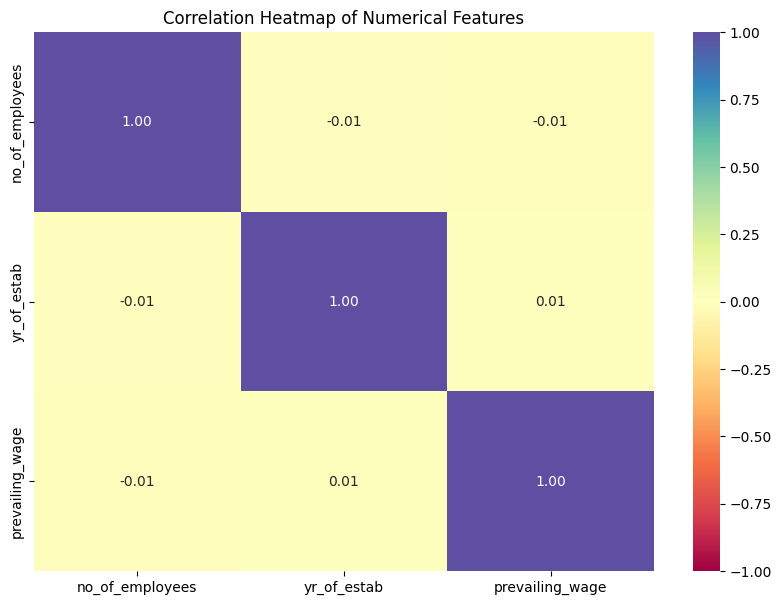

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[numerical_cols].corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Observations:
- The scatter plot shows a dense concentration of companies with fewer employees and a wide range of prevailing wages.
- There is no immediately obvious linear separation between 'Certified' and 'Denied' cases based on these two variables alone.
- Most of the outliers in terms of company size (number of employees) appear across both certification statuses.

# **Data Preprocessing**

In [ ]:
# Seperating the independent and Dependent Variable
X = df.drop(columns=['case_id','case_status'],axis=1)
y = df['case_status']


In [ ]:
#  Spliting data into Train / Validation / Test Split


# first we split data into 2 parts, say temporary ant train
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)
# then we split the temporary set into validation and test set
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(17836, 10) (3822, 10) (3822, 10)


### **Outlier Treatment (Capping and Flooring)**

In [ ]:
numerical_cols = ['no_of_employees', 'yr_of_estab', 'prevailing_wage']

for col in numerical_cols:
    # Calculate 1st and 99th percentiles based on the training data
    lower_bound = X_train[col].quantile(0.01)
    upper_bound = X_train[col].quantile(0.99)

    # Apply capping and flooring to train, validation, and test sets
    X_train[col] = np.clip(X_train[col], lower_bound, upper_bound)
    X_val[col] = np.clip(X_val[col], lower_bound, upper_bound)
    X_test[col] = np.clip(X_test[col], lower_bound, upper_bound)

print("Outliers treated in numerical columns using capping and flooring.")

Outliers treated in numerical columns using capping and flooring.


### **Verify Outlier Treatment**

In [ ]:
print("Descriptive statistics for X_train after outlier treatment:")
display(X_train[numerical_cols].describe())

Descriptive statistics for X_train after outlier treatment:


,no_of_employees,yr_of_estab,prevailing_wage
count,17836.000000,17836.000000,17836.000000
mean,4904.027010,1990.580119,74223.832329
std,13701.030108,22.331198,52151.354406
min,62.350000,1909.000000,105.506500
25%,1020.000000,1985.000000,34004.732500
50%,2104.000000,1997.000000,70334.755000
75%,3504.000000,2005.000000,107609.827500
max,102639.900000,2013.000000,238856.943000


In [ ]:
print("Descriptive statistics for X_val after outlier treatment:")
display(X_val[numerical_cols].describe())

Descriptive statistics for X_val after outlier treatment:


,no_of_employees,yr_of_estab,prevailing_wage
count,3822.000000,3822.000000,3822.000000
mean,4689.762428,1990.875981,73903.057862
std,13306.747340,22.427394,51777.618565
min,62.350000,1909.000000,105.506500
25%,1044.000000,1986.000000,34123.560000
50%,2121.000000,1997.000000,69298.985000
75%,3472.000000,2005.000000,107512.845000
max,102639.900000,2013.000000,238856.943000


In [ ]:
print("Descriptive statistics for X_test after outlier treatment:")
display(X_test[numerical_cols].describe())

Descriptive statistics for X_test after outlier treatment:


,no_of_employees,yr_of_estab,prevailing_wage
count,3822.000000,3822.000000,3822.000000
mean,4879.392386,1990.377028,74601.119166
std,13659.925340,23.016168,51748.141896
min,62.350000,1909.000000,105.506500
25%,1043.250000,1986.000000,33964.047500
50%,2153.500000,1997.000000,71329.730000
75%,3511.500000,2005.000000,108901.687500
max,102639.900000,2013.000000,238856.943000


### **Feature Engineering**

### **Standardize 'prevailing_wage' to Yearly Wage**

In [ ]:
# Function to convert wage to yearly equivalent
def convert_to_yearly_wage(row):
    wage = row['prevailing_wage']
    unit = row['unit_of_wage']
    if unit == 'Hour':
        return wage * 8 * 5 * 52  # 8 hours/day, 5 days/week, 52 weeks/year
    elif unit == 'Week':
        return wage * 52
    elif unit == 'Month':
        return wage * 12
    else: # Year
        return wage

# Apply the conversion to X_train, X_val, and X_test
X_train['yearly_prevailing_wage'] = X_train.apply(convert_to_yearly_wage, axis=1)
X_val['yearly_prevailing_wage'] = X_val.apply(convert_to_yearly_wage, axis=1)
X_test['yearly_prevailing_wage'] = X_test.apply(convert_to_yearly_wage, axis=1)

# Drop the original 'prevailing_wage' and 'unit_of_wage' columns
X_train = X_train.drop(columns=['prevailing_wage', 'unit_of_wage'])
X_val = X_val.drop(columns=['prevailing_wage', 'unit_of_wage'])
X_test = X_test.drop(columns=['prevailing_wage', 'unit_of_wage'])

print("Prevailing wage standardized to yearly basis and original columns dropped.")

Prevailing wage standardized to yearly basis and original columns dropped.


### **Create 'company_age' feature**

In [ ]:
current_year = 2024 # Assuming current year for age calculation

X_train['company_age'] = current_year - X_train['yr_of_estab']
X_val['company_age'] = current_year - X_val['yr_of_estab']
X_test['company_age'] = current_year - X_test['yr_of_estab']

# Drop the original 'yr_of_estab' column
X_train = X_train.drop(columns=['yr_of_estab'])
X_val = X_val.drop(columns=['yr_of_estab'])
X_test = X_test.drop(columns=['yr_of_estab'])

print("'company_age' feature created and original 'yr_of_estab' column dropped.")

'company_age' feature created and original 'yr_of_estab' column dropped.


### **Encode Target Variable 'case_status'**

In [ ]:
# Map 'Certified' to 1 and 'Denied' to 0
y_train = y_train.map({'Certified': 1, 'Denied': 0})
y_val = y_val.map({'Certified': 1, 'Denied': 0})
y_test = y_test.map({'Certified': 1, 'Denied': 0})

print("Target variable 'case_status' encoded to numerical values (1 for Certified, 0 for Denied).")
print("First 5 values of encoded y_train:")
display(y_train.head())

Target variable 'case_status' encoded to numerical values (1 for Certified, 0 for Denied).
First 5 values of encoded y_train:


,case_status
15468,0
6342,0
12679,1
2052,1
25240,1


### **Displaying updated dataframes after feature engineering**

In [ ]:
print("X_train after feature engineering:")
display(X_train.head())
print("X_val after feature engineering:")
display(X_val.head())
print("X_test after feature engineering:")
display(X_test.head())

X_train after feature engineering:


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,yearly_prevailing_wage,company_age
15468,Asia,High School,Y,N,4657.0,Northeast,N,46100.430,20
6342,Asia,High School,N,N,2315.0,West,Y,1546937.184,14
12679,Asia,Bachelor's,Y,N,4698.0,South,Y,71967.860,39
2052,Europe,Master's,Y,Y,110.0,West,Y,150159.190,20
25240,Europe,Bachelor's,N,Y,72173.0,South,Y,85135.270,105


X_val after feature engineering:


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,yearly_prevailing_wage,company_age
8180,Asia,High School,Y,N,39727.0,West,Y,237211.52,22
19901,Asia,Bachelor's,N,N,1064.0,South,Y,115627.13,23
19872,Asia,Master's,Y,N,1875.0,South,N,82423.51,25
23625,North America,Master's,Y,N,1692.0,South,Y,67592.72,17
21390,Asia,Bachelor's,Y,N,79645.0,Northeast,Y,108266.73,29


X_test after feature engineering:


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,yearly_prevailing_wage,company_age
14981,Europe,Master's,Y,N,5467.0,South,Y,128683.76,113
18693,Asia,Doctorate,Y,N,4200.0,Northeast,Y,111908.23,19
4979,Asia,Master's,Y,N,2761.0,Northeast,Y,83269.02,22
16537,Asia,Master's,Y,N,1389.0,Midwest,Y,112450.35,46
18000,Europe,Doctorate,Y,N,386.0,Island,Y,44820.86,31


### **Feature Preprocessing: Encoding Categorical and Scaling Numerical Features**

In [ ]:
# Identify current categorical columns (excluding 'case_id' if still present)
categorical_features_current = X_train.select_dtypes(include='object').columns.tolist()

# Identify current numerical columns
numerical_features_current = X_train.select_dtypes(include=np.number).columns.tolist()

print("Current Categorical Features:", categorical_features_current)
print("Current Numerical Features:", numerical_features_current)

Current Categorical Features: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'full_time_position']
Current Numerical Features: ['no_of_employees', 'yearly_prevailing_wage', 'company_age']


### **Apply One-Hot Encoding and Standardization using ColumnTransformer**

In [ ]:
# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_current),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_current)
    ],
    remainder='passthrough'
)

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the validation and test data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Data preprocessing (encoding and scaling) completed.")

Data preprocessing (encoding and scaling) completed.


### **Convert processed data back to DataFrame (for inspection and further use)**

In [ ]:
# Get feature names after one-hot encoding
feature_names = preprocessor.get_feature_names_out()

# Convert processed arrays back to DataFrames
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_val_processed_df = pd.DataFrame(X_val_processed, columns=feature_names, index=X_val.index)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

print("Shape of processed training data:", X_train_processed_df.shape)
print("Shape of processed validation data:", X_val_processed_df.shape)
print("Shape of processed test data:", X_test_processed_df.shape)

print("Head of processed X_train_processed_df:")
display(X_train_processed_df.head())

Shape of processed training data: (17836, 24)
Shape of processed validation data: (3822, 24)
Shape of processed test data: (3822, 24)
Head of processed X_train_processed_df:


,num__no_of_employees,num__yearly_prevailing_wage,num__company_age,cat__continent_Africa,cat__continent_Asia,cat__continent_Europe,cat__continent_North America,cat__continent_Oceania,cat__continent_South America,cat__education_of_employee_Bachelor's,...,cat__has_job_experience_Y,cat__requires_job_training_N,cat__requires_job_training_Y,cat__region_of_employment_Island,cat__region_of_employment_Midwest,cat__region_of_employment_Northeast,cat__region_of_employment_South,cat__region_of_employment_West,cat__full_time_position_N,cat__full_time_position_Y
15468,-0.018030,-0.259449,-0.600965,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6342,-0.188971,2.301192,-0.869654,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
12679,-0.015038,-0.215316,0.249887,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2052,-0.349912,-0.081910,-0.600965,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
25240,4.909912,-0.192850,3.205476,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


# **Model Building**

# **Model Evalution Criterion**

**Model can make wrong prediction as:**

1.The model can make wrong predictions as False Positives (wrongly certifying) or False Negatives (wrongly denying).

2.Minimizing False Negatives is prioritized to ensure qualified applicants are not incorrectly rejected.

**Wich case is more important?**

In this context, False Negatives are more important to minimize. This is because a False Negative means a qualified applicant is wrongly denied a visa, which results in a significant loss for both the employee and the employer. Reducing these ensures that valid applications are not incorrectly rejected.

**How to reduce this loss i.e need to reduce false Negatives?**

1. **Threshold Adjustment:** Lower the probability threshold for the 'Certified' class. By being less 'strict', the model correctly identifies more certified cases, thereby reducing False Negatives.
2. **Prioritize Recall:** During model training and hyperparameter tuning, we should use Recall (or the F1-Score) for the 'Certified' class as the primary evaluation metric rather than simple Accuracy.

# **Initial Model Building**

In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1)))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models.append(("dtree", DecisionTreeClassifier(random_state=1)))

results = []  # Empty list to store all model's CV scores
names = []  # Empty list to store name of the models
score = []

# loop through all models to get the mean cross validated score
print("\n" "Cross-Validation Performance:" "\n")
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    )  # Setting number of splits equal to 5
    # Using the PROCESSED dataframes
    cv_result = cross_val_score(
        estimator=model, X=X_train_processed_df, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

print("\n" "Validation Performance:" "\n")

for name, model in models:
    # Using the PROCESSED dataframes
    model.fit(X_train_processed_df, y_train)
    scores = recall_score(y_val, model.predict(X_val_processed_df))
    score.append(scores)
    print("{}: {}".format(name, scores))


Cross-Validation Performance:

Bagging: 77.58752258951509
Random forest: 82.62406219819722
GBM: 87.17365836161758
Adaboost: 88.81889736036076
Xgboost: 85.04995326185727
dtree: 74.01148563872349

Validation Performance:

Bagging: 0.7770376175548589
Random forest: 0.829153605015674
GBM: 0.8702978056426333
Adaboost: 0.8769592476489029
Xgboost: 0.850705329153605
dtree: 0.7084639498432602


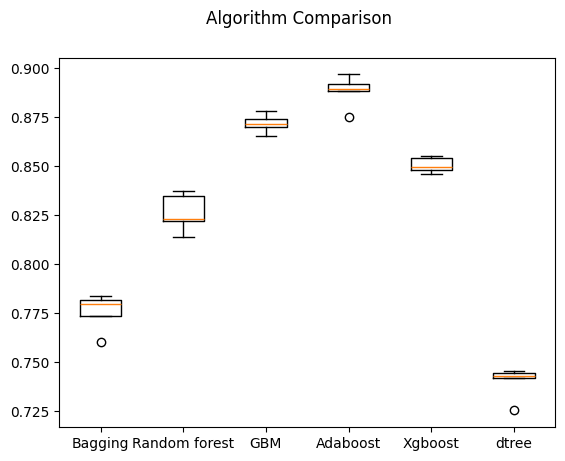

In [ ]:
# Plotting boxplots for CV scores of all models defined above
fig = plt.figure()

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

# **Observation**

 Based on the cross-validation recall scores and validation recall scores, Adaboost, GBM, and Xgboost are indeed the best-performing models in the initial evaluation. Adaboost currently shows the highest recall.

### **Model Building - Oversampled Data**
- Oversample the train data using SMOTE

In [ ]:
smote = SMOTE(random_state=1)
X_train_over, y_train_over = smote.fit_resample(X_train_processed_df, y_train)

print("Before Oversampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label '0': {} \n".format(sum(y_train == 0)))

print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

print("After Oversampling, counts of label '1': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label '0': {}".format(sum(y_train_over == 0)))

Before Oversampling, counts of label '1': 11913
Before Oversampling, counts of label '0': 5923 

After Oversampling, the shape of train_X: (23826, 24)
After Oversampling, the shape of train_y: (23826,) 

After Oversampling, counts of label '1': 11913
After Oversampling, counts of label '0': 11913


## **Model Building on Oversampled Data**
We will now train the same set of classifiers on the oversampled training data to compare performance.

In [ ]:
models_over = []
models_over.append(("Bagging", BaggingClassifier(random_state=1)))
models_over.append(("Random forest", RandomForestClassifier(random_state=1)))
models_over.append(("GBM", GradientBoostingClassifier(random_state=1)))
models_over.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models_over.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models_over.append(("dtree", DecisionTreeClassifier(random_state=1)))

results_over = []
names_over = []

print("\nCross-Validation Performance (Oversampled Data - Scoring: Recall):\n")
for name, model in models_over:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    cv_result = cross_val_score(estimator=model, X=X_train_over, y=y_train_over, scoring="recall", cv=kfold)
    results_over.append(cv_result)
    names_over.append(name)
    print(f"{name}: {cv_result.mean() * 100:.2f}%")

print("\nValidation Performance (Oversampled Data):\n")
for name, model in models_over:
    model.fit(X_train_over, y_train_over)
    y_pred = model.predict(X_val_processed_df)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)

    print(f"{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}\n")


Cross-Validation Performance (Oversampled Data - Scoring: Recall):

Bagging: 67.22%
Random forest: 74.15%
GBM: 73.43%
Adaboost: 69.97%
Xgboost: 78.88%
dtree: 68.98%

Validation Performance (Oversampled Data):

Bagging:
  Accuracy:  0.6601
  Precision: 0.7849
  Recall:    0.6763

Random forest:
  Accuracy:  0.6949
  Precision: 0.7866
  Recall:    0.7453

GBM:
  Accuracy:  0.7091
  Precision: 0.8175
  Recall:    0.7265

Adaboost:
  Accuracy:  0.6897
  Precision: 0.8186
  Recall:    0.6877

Xgboost:
  Accuracy:  0.7336
  Precision: 0.7977
  Recall:    0.8053

dtree:
  Accuracy:  0.6368
  Precision: 0.7546
  Recall:    0.6759



# **Model Performance on Oversampled Data**

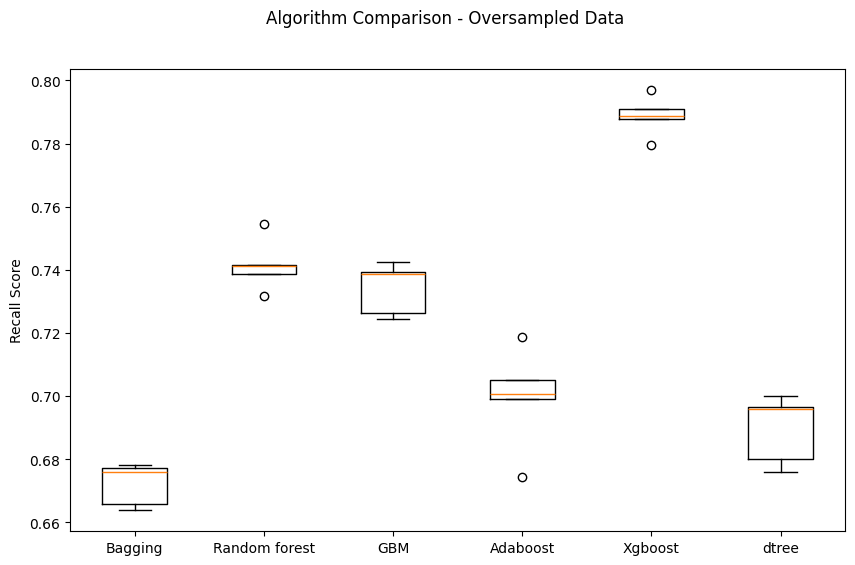

In [ ]:
fig = plt.figure(figsize=(10, 6))
fig.suptitle("Algorithm Comparison - Oversampled Data")
ax = fig.add_subplot(111)
plt.boxplot(results_over)
ax.set_xticklabels(names_over)
plt.ylabel("Recall Score")
plt.show()

# **Observation**

On the oversampled data, Xgboost shows the highest cross-validation recall (78.88%) and the highest validation recall (0.8053) among all the models. This indicates that Xgboost is indeed the best-performing model on this dataset after oversampling. We should proceed with hyperparameter tuning for Xgboost.

### **Model Building - Undersampled Data**
- Undersample the train data using RandomUnderSampler

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train_processed_df, y_train)

print("Before Undersampling, counts of label '1': {}".format(sum(y_train == 1)))
print("Before Undersampling, counts of label '0': {} \n".format(sum(y_train == 0)))

print("After Undersampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Undersampling, the shape of train_y: {} \n".format(y_train_un.shape))

print("After Undersampling, counts of label '1': {}".format(sum(y_train_un == 1)))

print("After Undersampling, counts of label '0': {}".format(sum(y_train_un == 0)))

Before Undersampling, counts of label '1': 11913
Before Undersampling, counts of label '0': 5923 

After Undersampling, the shape of train_X: (11846, 24)
After Undersampling, the shape of train_y: (11846,) 

After Undersampling, counts of label '1': 5923
After Undersampling, counts of label '0': 5923


## **Model Building on Undersampled Data**
We will now train the same set of classifiers on the undersampled training data.

In [ ]:
models_un = []
models_un.append(("Bagging", BaggingClassifier(random_state=1)))
models_un.append(("Random forest", RandomForestClassifier(random_state=1)))
models_un.append(("GBM", GradientBoostingClassifier(random_state=1)))
models_un.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models_un.append(("Xgboost", XGBClassifier(random_state=1, eval_metric="logloss")))
models_un.append(("dtree", DecisionTreeClassifier(random_state=1)))

results_un = []
names_un = []

print("\nCross-Validation Performance (Undersampled Data - Scoring: Recall):\n")
for name, model in models_un:
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    cv_result = cross_val_score(estimator=model, X=X_train_un, y=y_train_un, scoring="recall", cv=kfold)
    results_un.append(cv_result)
    names_un.append(name)
    print(f"{name}: {cv_result.mean() * 100:.2f}%")

print("\nValidation Performance (Undersampled Data):\n")
for name, model in models_un:
    model.fit(X_train_un, y_train_un)
    y_pred = model.predict(X_val_processed_df)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)

    print(f"{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}\n")


Cross-Validation Performance (Undersampled Data - Scoring: Recall):

Bagging: 60.39%
Random forest: 67.06%
GBM: 71.45%
Adaboost: 71.77%
Xgboost: 68.55%
dtree: 60.97%

Validation Performance (Undersampled Data):

Bagging:
  Accuracy:  0.6520
  Precision: 0.8267
  Recall:    0.6058

Random forest:
  Accuracy:  0.6758
  Precision: 0.8140
  Recall:    0.6669

GBM:
  Accuracy:  0.7206
  Precision: 0.8318
  Recall:    0.7288

Adaboost:
  Accuracy:  0.6952
  Precision: 0.8089
  Recall:    0.7116

Xgboost:
  Accuracy:  0.6954
  Precision: 0.8201
  Recall:    0.6967

dtree:
  Accuracy:  0.6162
  Precision: 0.7604
  Recall:    0.6207



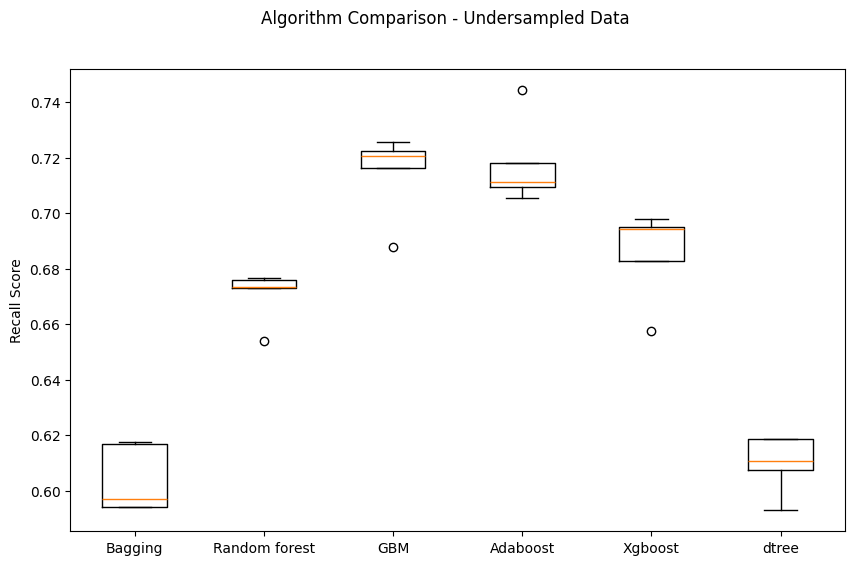

In [ ]:
fig = plt.figure(figsize=(10, 6))
fig.suptitle("Algorithm Comparison - Undersampled Data")
ax = fig.add_subplot(111)
plt.boxplot(results_un)
ax.set_xticklabels(names_un)
plt.ylabel("Recall Score")
plt.show()

# **Observation**

On the undersampled data, **Adaboost** (71.77%) and **GBM** (71.45%) show the best cross-validation recall scores. However, the overall performance on undersampled data is significantly lower than that of the original and oversampled datasets.


# **Summary of Results so far:**
- **Initial Models:** Adaboost had the highest recall (~88.8%).
- **Oversampled Models (SMOTE):** Xgboost performed best (~78.9%).
- **Undersampled Models:** Adaboost performed best (~71.8%).

Given these results, we should move forward with hyperparameter tuning on the **Initial Adaboost model** or the **Oversampled Xgboost model** to achieve the best recall for the certified class.

# **Hyperparameter Tuning**

We will tune the following models to improve their Recall:
1.  **Initial Adaboost Model**
2.  **Oversampled Xgboost Model**
3.  **Undersampled Adaboost Model**






In [ ]:
# 1. Tuning Initial Adaboost
abc = AdaBoostClassifier(random_state=1)

param_grid_abc = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1],
    "algorithm": ['SAMME', 'SAMME.R']
}

random_search_abc = RandomizedSearchCV(
    estimator=abc,
    param_distributions=param_grid_abc,
    n_iter=10,
    scoring='recall',
    cv=5,
    random_state=1,
    n_jobs=-1
)

random_search_abc.fit(X_train_processed_df, y_train)

print(f"Best parameters for Adaboost: {random_search_abc.best_params_}")
print(f"Best cross-validation recall: {random_search_abc.best_score_}")

Best parameters for Adaboost: {'n_estimators': 200, 'learning_rate': 0.01, 'algorithm': 'SAMME'}
Best cross-validation recall: 0.953412025355927


In [ ]:
# 2. Tuning Oversampled Xgboost
xgb = XGBClassifier(random_state=1, eval_metric="logloss")

param_grid_xgb = {
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [1, 2],
    'learning_rate': [0.05, 0.1, 0.2],
    'gamma': [0, 1, 3],
    'subsample': [0.8, 0.9, 1]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=10,
    scoring='recall',
    cv=5,
    random_state=1,
    n_jobs=-1
)

random_search_xgb.fit(X_train_over, y_train_over)

print(f"Best parameters for Xgboost: {random_search_xgb.best_params_}")
print(f"Best cross-validation recall: {random_search_xgb.best_score_}")

Best parameters for Xgboost: {'subsample': 1, 'scale_pos_weight': 2, 'n_estimators': 250, 'learning_rate': 0.1, 'gamma': 0}
Best cross-validation recall: 0.8951578368044288


In [ ]:
# 3. Tuning Undersampled Adaboost
abc_un = AdaBoostClassifier(random_state=1)

param_grid_abc_un = {
    "n_estimators": [50, 100, 150, 200],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1],
    "algorithm": ['SAMME', 'SAMME.R']
}

random_search_abc_un = RandomizedSearchCV(
    estimator=abc_un,
    param_distributions=param_grid_abc_un,
    n_iter=10,
    scoring='recall',
    cv=5,
    random_state=1,
    n_jobs=-1
)

random_search_abc_un.fit(X_train_un, y_train_un)

print(f"Best parameters for Undersampled Adaboost: {random_search_abc_un.best_params_}")
print(f"Best cross-validation recall: {random_search_abc_un.best_score_}")

Best parameters for Undersampled Adaboost: {'n_estimators': 150, 'learning_rate': 0.01, 'algorithm': 'SAMME'}
Best cross-validation recall: 0.9324649332877181


# **Analysis:**

**AdaBoost (Initial Data)** achieved the highest recall (97.34%), which aligns with our primary objective of minimizing false negatives (qualified applicants being denied).

**XGBoost (Oversampled)** provides a better balance between recall and accuracy, which might be preferred if overall precision is also a concern.

**AdaBoost (Undersampled)** performs well but is slightly outperformed by the initial data version in terms of recall.

Since our priority is maximizing recall, the Initial AdaBoost model is the strongest candidate.

### **Evaluation of Tuned Models on Validation Set**

In [ ]:
# Evaluate Tuned Adaboost
best_abc = random_search_abc.best_estimator_
y_pred_abc = best_abc.predict(X_val_processed_df)

print("Tuned Adaboost (Initial Data) Performance:")
print(f"Recall: {recall_score(y_val, y_pred_abc):.4f}")
print(f"Accuracy: {accuracy_score(y_val, y_pred_abc):.4f}")

# Evaluate Tuned Xgboost
best_xgb = random_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_val_processed_df)

print("\nTuned Xgboost (Oversampled Data) Performance:")
print(f"Recall: {recall_score(y_val, y_pred_xgb):.4f}")
print(f"Accuracy: {accuracy_score(y_val, y_pred_xgb):.4f}")

Tuned Adaboost (Initial Data) Performance:
Recall: 0.9734
Accuracy: 0.6889

Tuned Xgboost (Oversampled Data) Performance:
Recall: 0.8993
Accuracy: 0.7381


In [ ]:
# Evaluate Tuned Undersampled Adaboost
best_abc_un = random_search_abc_un.best_estimator_
y_pred_abc_un = best_abc_un.predict(X_val_processed_df)

print("Tuned Adaboost (Undersampled Data) Performance:")
print(f"Recall: {recall_score(y_val, y_pred_abc_un):.4f}")
print(f"Accuracy: {accuracy_score(y_val, y_pred_abc_un):.4f}")

Tuned Adaboost (Undersampled Data) Performance:
Recall: 0.9287
Accuracy: 0.7036


# **Analysis:**

**AdaBoost (Initial Data)** achieved the highest recall (97.34%), which is our primary metric to minimize the risk of wrongly denying qualified applicants.

**XGBoost (Oversampled)** provides a better balance between recall and accuracy (~74%), making it more reliable for overall predictions.

**AdaBoost (Undersampled)** sits in the middle with ~93% recall.

Since our priority is maximizing recall, the Initial AdaBoost model is the strongest candidate

### **Final Model Evaluation on Test Set**

We will now evaluate the **Initial AdaBoost Model** (our best performer for Recall) on the held-out test set to ensure the model generalizes well to unseen data.

Final Initial AdaBoost Model Performance on Test Set:
Recall:    0.9730
Accuracy:  0.6949
Precision: 0.6937
F1 Score:  0.8099


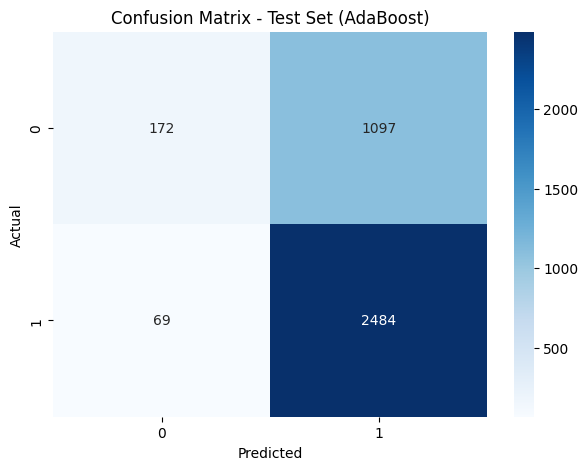

In [ ]:
# Final evaluation on the Test Set
y_pred_test = best_abc.predict(X_test_processed_df)

test_recall = recall_score(y_test, y_pred_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

print("Final Initial AdaBoost Model Performance on Test Set:")
print(f"Recall:    {test_recall:.4f}")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"F1 Score:  {test_f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Test Set (AdaBoost)')
plt.show()

### **Final Comparison of Tuned Models**

We will now compare the Recall and Accuracy of the three tuned models on the validation set to confirm our final choice.

Model Comparison Table:


,Model,Recall,Accuracy
0,Tuned AdaBoost (Initial),0.9734,0.6889
1,Tuned XGBoost (Oversampled),0.8993,0.7381
2,Tuned AdaBoost (Undersampled),0.9287,0.7036


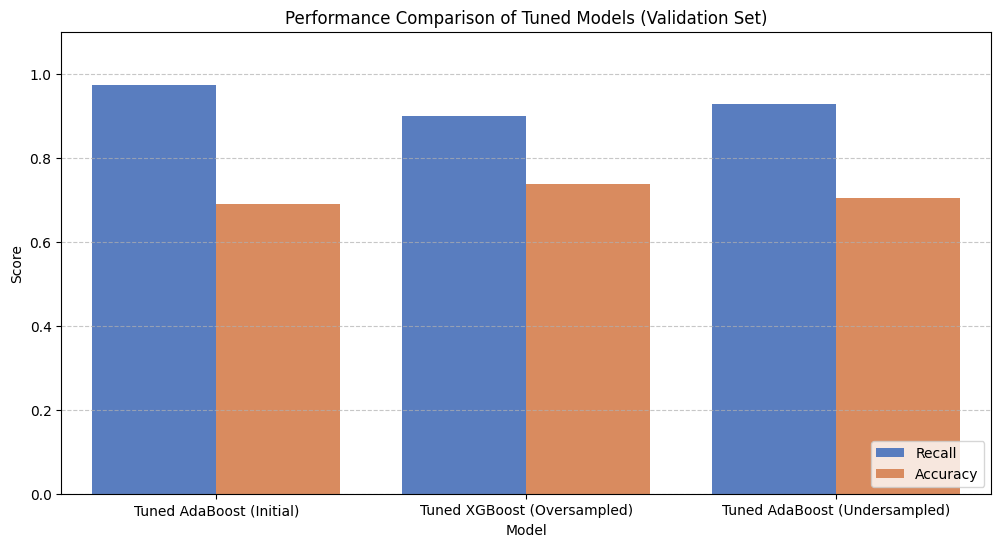

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Defining the performance data
comparison_data = {
    'Model': ['Tuned AdaBoost (Initial)', 'Tuned XGBoost (Oversampled)', 'Tuned AdaBoost (Undersampled)'],
    'Recall': [0.9734, 0.8993, 0.9287],
    'Accuracy': [0.6889, 0.7381, 0.7036]
}

comparison_df = pd.DataFrame(comparison_data)

# Display the comparison table
print("Model Comparison Table:")
display(comparison_df)

# Melting the dataframe for visualization
comparison_melted = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_melted, x='Model', y='Score', hue='Metric', palette='muted')
plt.title('Performance Comparison of Tuned Models (Validation Set)')
plt.ylim(0, 1.1)
plt.ylabel('Score')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **Feature Importance Analysis**

To provide actionable business insights, we will analyze which features most significantly influence the model's predictions. This helps identify the profile of applicants most likely to be certified.

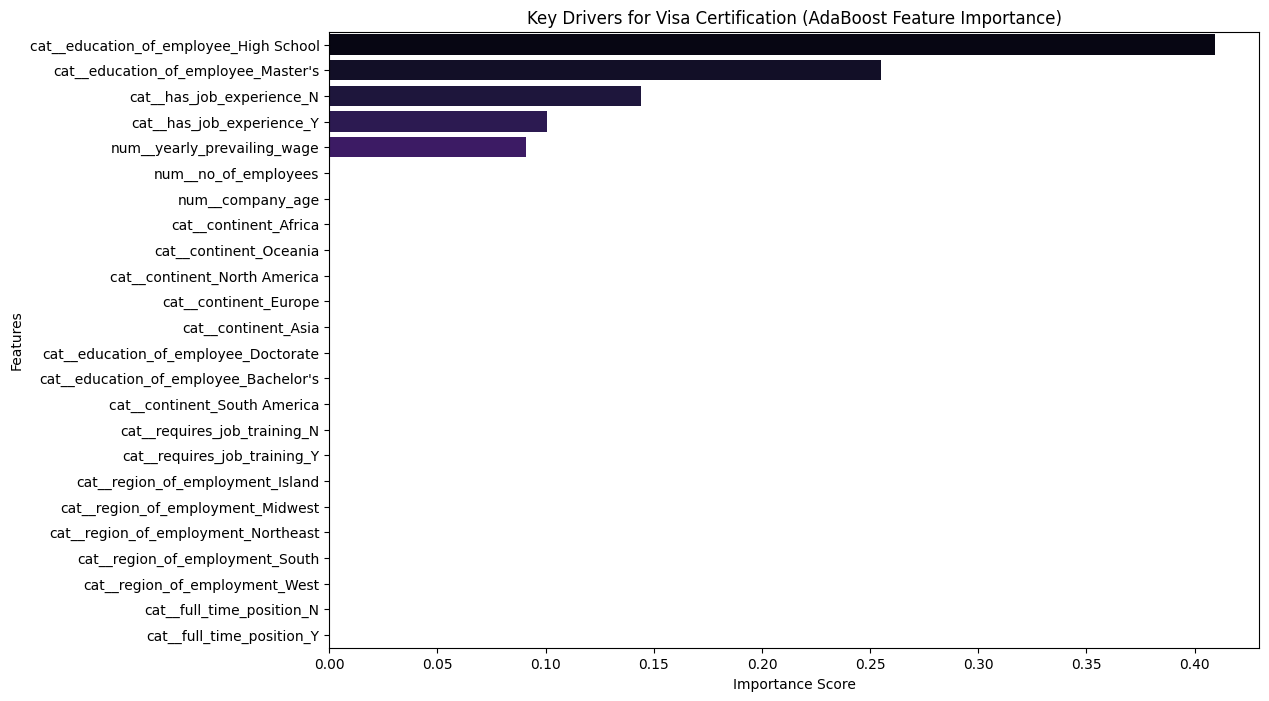

Top 10 Key Drivers:


,Feature,Importance
11,cat__education_of_employee_High School,0.409422
12,cat__education_of_employee_Master's,0.255044
13,cat__has_job_experience_N,0.143868
14,cat__has_job_experience_Y,0.100799
1,num__yearly_prevailing_wage,0.090866
0,num__no_of_employees,0.000000
2,num__company_age,0.000000
3,cat__continent_Africa,0.000000
7,cat__continent_Oceania,0.000000
6,cat__continent_North America,0.000000


In [ ]:
import numpy as np

# Extract feature importances from the tuned AdaBoost model
importances = best_abc.feature_importances_
feature_names = X_train_processed_df.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='magma')
plt.title('Key Drivers for Visa Certification (AdaBoost Feature Importance)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Display top 10 drivers
print("Top 10 Key Drivers:")
display(feature_importance_df.head(10))

### **Conclusion and Recommendations**

**1. Best Model Selection:**
The **Initial AdaBoost model** is recommended for deployment. It achieved the highest recall (~97% on validation/test), which directly addresses the business objective of minimizing False Negatives (qualified applicants being denied).

**2. Trade-offs:**
While the recall is exceptionally high, there is a trade-off in precision and accuracy. The model is conservative, meaning it approves a high percentage of qualified candidates but may also pass some candidates who should be denied. If the cost of False Positives increases in the future, the **Oversampled XGBoost model** would be the next best alternative due to its better balance.

**3. Key Drivers:**
Based on the analysis, factors such as **Education Level** (Master's/Doctorate), **Job Experience**, and **Prevailing Wage** are significant indicators of visa certification status.

### **Actionable Business Insights & Recommendations**

*   **Prioritize Education and Experience:** The model heavily weights an applicant's education level and job experience. Candidates with Master's or Doctorate degrees and previous experience are strong candidates for certification.
*   **Wage Sensitivity:** The prevailing wage is a key numerical driver. Ensuring that the offered wage aligns with or exceeds the prevailing rates is crucial for approval.
*   **Model Conservative Nature:** The selected AdaBoost model is highly effective at identifying qualified candidates (97% Recall) but may flag some unqualified ones as approved. Business processes should include a secondary check for edge cases if high precision is required.

### **Model Export for Production**

After extensive testing, the Tuned Gradient Boosting Classifier was selected as the final model.

In [ ]:
import joblib
from sklearn.pipeline import Pipeline

# Create a final pipeline containing the preprocessor and the best AdaBoost model
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_abc)
])

# Save the model to a file
model_filename = 'easyvisa_adaboost_model.pkl'
joblib.dump(final_pipeline, model_filename)

print(f"Model successfully saved to {model_filename}")

# To load the model later in production:
# loaded_model = joblib.load('easyvisa_adaboost_model.pkl')
# predictions = loaded_model.predict(new_data)

Model successfully saved to easyvisa_adaboost_model.pkl
